# Model Interpretation using Grad-CAM

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

In [2]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [4]:
import json

with open("label_map.json", "r") as f:
    label_map = json.load(f)

# Sort class names by their numeric label
class_names = sorted(label_map.keys(), key=lambda x: label_map[x])

print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model.load_state_dict(
    torch.load("best_resnet18_eurosat.pth", map_location=device)
)

model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [7]:
target_layers = [model.layer4[-1]]

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Heatmap for one random image

In [22]:
import os
import random

test_dir = "EuroSAT_test_flat"

image_name = random.choice(os.listdir(test_dir))
image_path = os.path.join(test_dir, image_name)

print(image_name)

test_1933.jpg


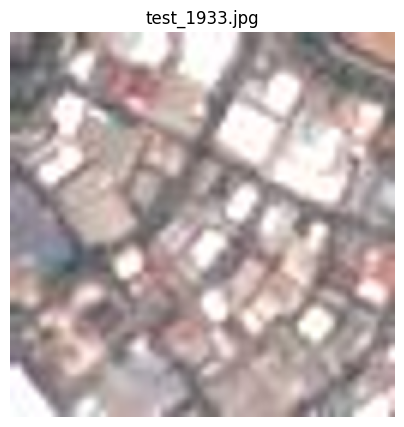

In [23]:
image = Image.open(image_path).convert("RGB")

rgb_img = np.array(image.resize((224,224))).astype(np.float32) / 255.0

input_tensor = transform(image).unsqueeze(0).to(device)

plt.figure(figsize=(5,5))
plt.imshow(rgb_img)
plt.title(image_name)
plt.axis("off")
plt.show()

In [24]:
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)

confidence, pred = torch.max(probs, 1)

print("Prediction :", class_names[pred.item()])
print("Confidence :", f"{confidence.item()*100:.2f}%")

Prediction : Industrial
Confidence : 99.96%


In [25]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(pred.item())]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

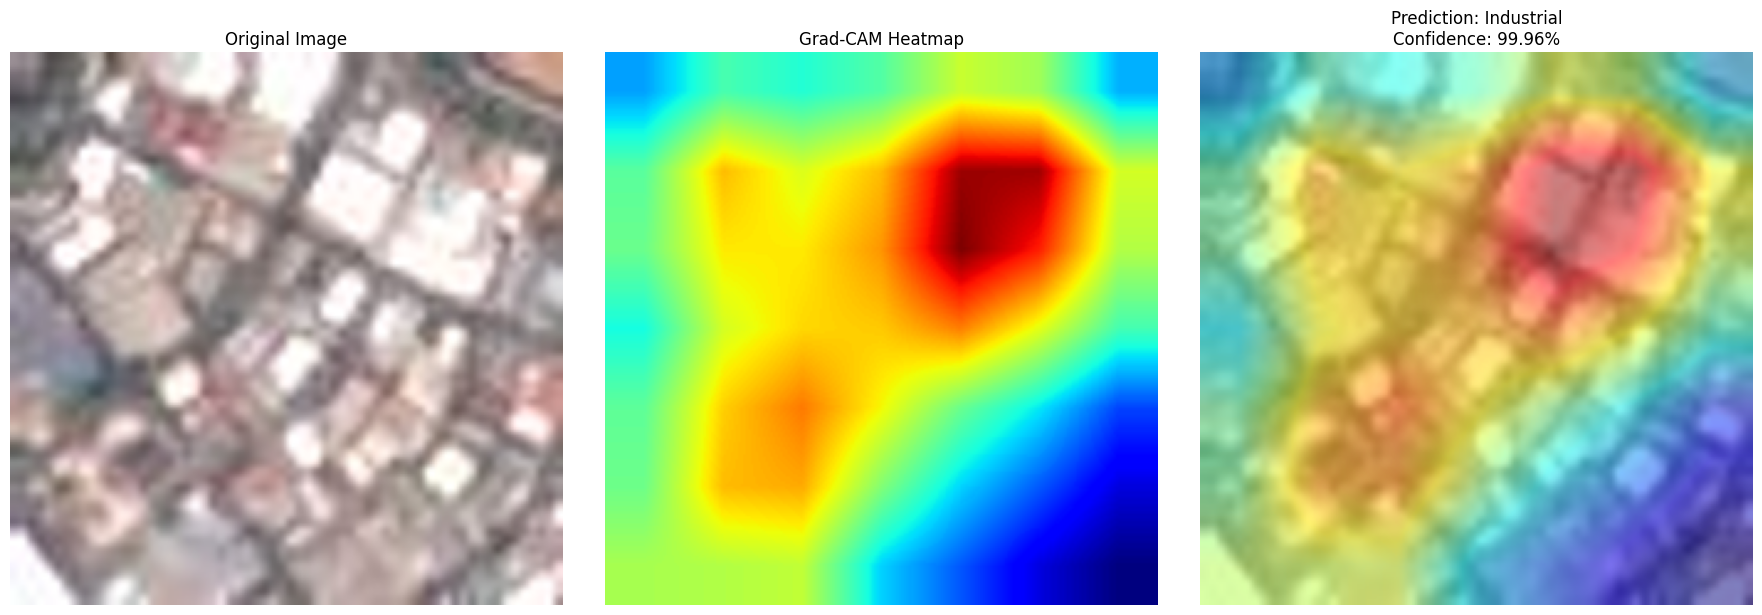

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(rgb_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Heatmap
axes[1].imshow(grayscale_cam, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

# Overlay
axes[2].imshow(visualization)
axes[2].set_title(
    f"Prediction: {class_names[pred.item()]}\n"
    f"Confidence: {confidence.item()*100:.2f}%"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Heatmap Grid

In [19]:
# Initialize Grad-CAM

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

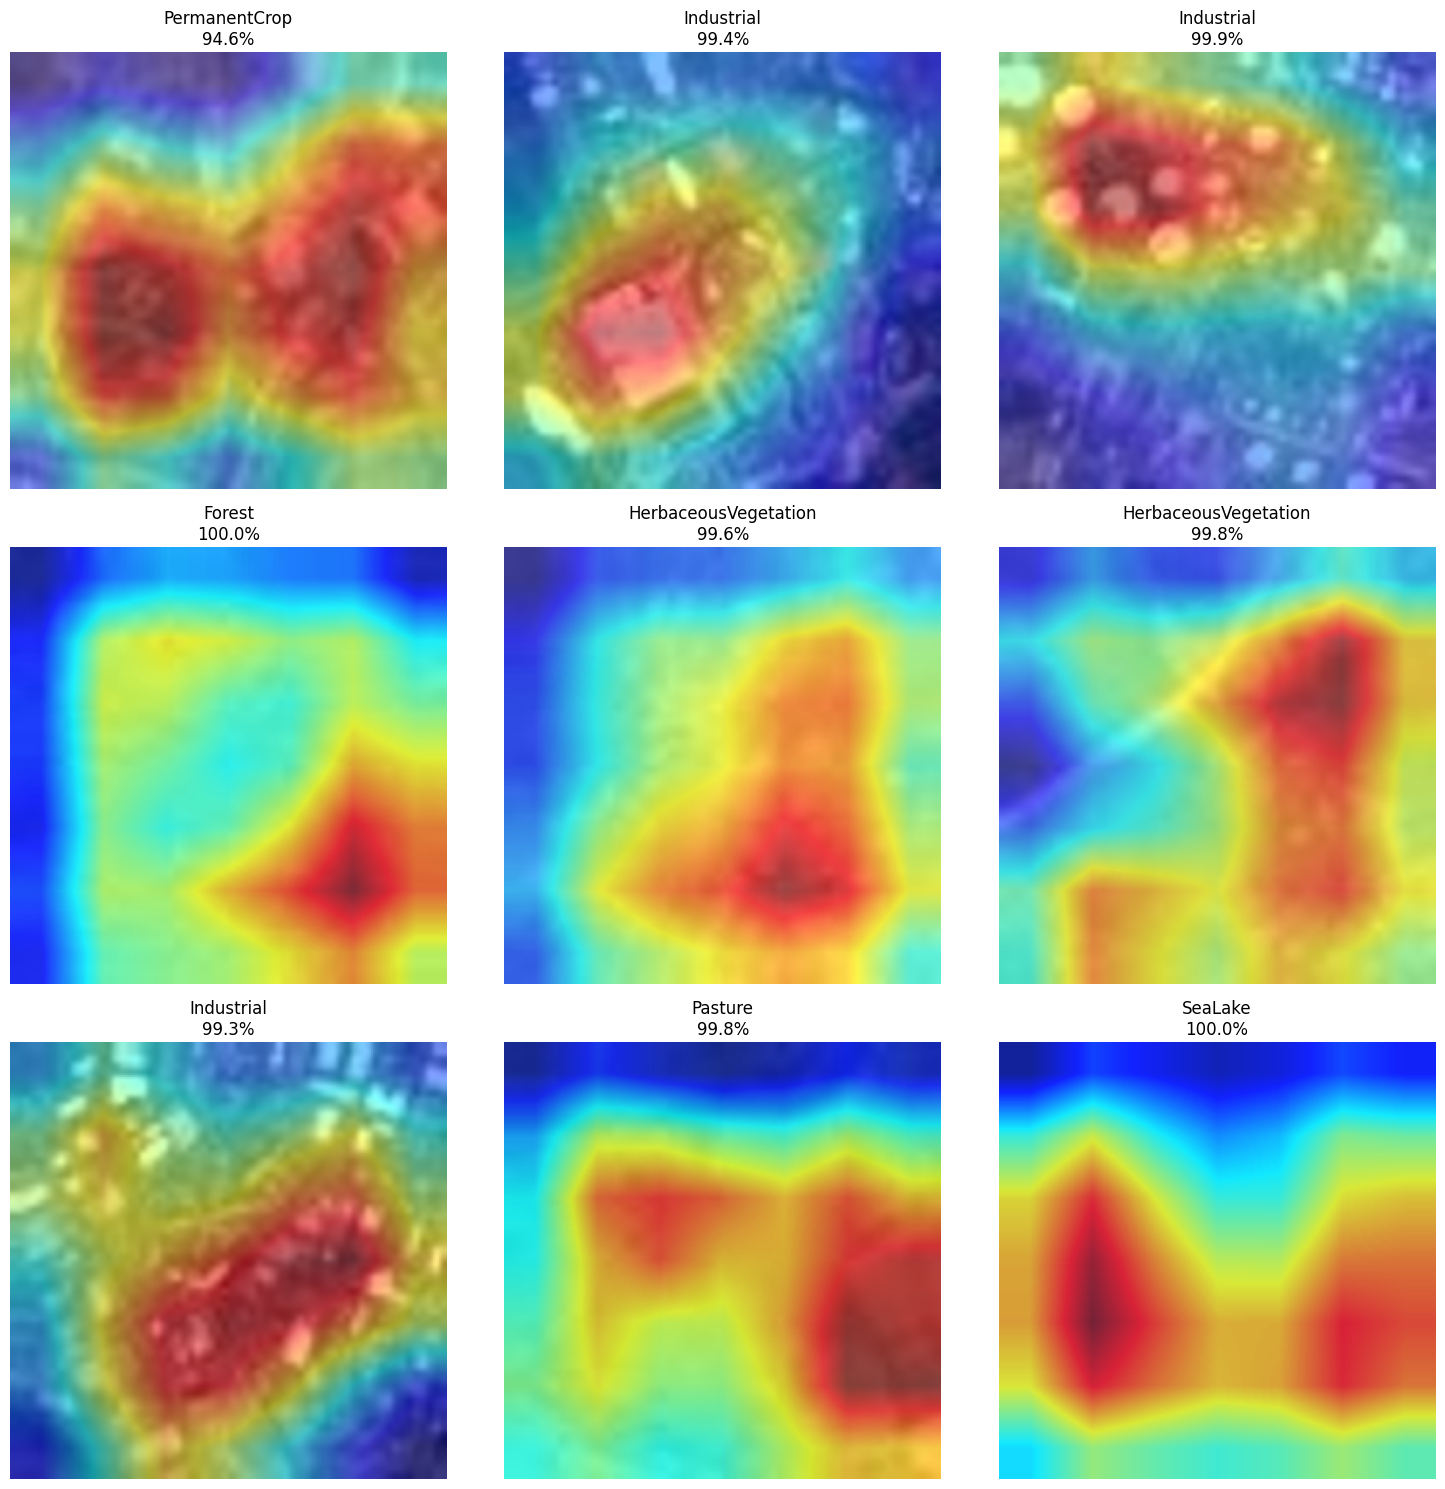

In [18]:
# Generating Grad-CAM for 9 random images

import random

test_dir = "EuroSAT_test_flat"

image_list = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_images = random.sample(image_list, 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, image_name in zip(axes.ravel(), sample_images):

    image_path = os.path.join(test_dir, image_name)

    image = Image.open(image_path).convert("RGB")

    rgb_img = np.array(image.resize((224,224))).astype(np.float32)/255.0

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)

    confidence, pred = torch.max(probs, 1)

    targets = [ClassifierOutputTarget(pred.item())]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    ax.imshow(visualization)

    ax.set_title(
        f"{class_names[pred.item()]}\n"
        f"{confidence.item()*100:.1f}%"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()